# Clasp Queens surrogate countercheck

This notebook separates **call-path correctness** from **statistical fidelity**. The exact parity test checks the official ACLib request conversion/prediction path against the in-process adapter used by our SMAC experiments. The remaining sections compare the packaged EPM with archived real Clasp measurements.

The archived measurements contributed to EPM construction, so these results are an integrity/reproduction diagnostic rather than an independent generalization result. The point-level sample is deliberately balanced across five runtime/status strata; its aggregate error metrics are diagnostic and are not estimates under the archive's natural class frequencies.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd().resolve()
RESULTS = HERE / 'results'
required = [
    RESULTS / 'summary.json',
    RESULTS / 'wrapper_parity.csv',
    RESULTS / 'command_line_wrapper_parity.csv',
    RESULTS / 'point_level.csv',
    RESULTS / 'full_training.csv',
    RESULTS / 'uncertainty.csv',
    RESULTS / 'five_seed_summary.json',
    RESULTS / 'five_seed_pairs.csv',
    RESULTS / 'five_seed_actual_costs.npy',
    RESULTS / 'five_seed_surrogate_draws.npy',
]
missing = [str(path) for path in required if not path.is_file()]
if missing:
    raise FileNotFoundError('Run ./run_validation.py first. Missing:\n' + '\n'.join(missing))

summary = json.loads((RESULTS / 'summary.json').read_text())
parity = pd.read_csv(RESULTS / 'wrapper_parity.csv')
cli_parity = pd.read_csv(RESULTS / 'command_line_wrapper_parity.csv')
points = pd.read_csv(RESULTS / 'point_level.csv')
full = pd.read_csv(RESULTS / 'full_training.csv')
uncertainty = pd.read_csv(RESULTS / 'uncertainty.csv')
five_seed_summary = json.loads((RESULTS / 'five_seed_summary.json').read_text())
five_seed_pairs = pd.read_csv(RESULTS / 'five_seed_pairs.csv')
five_seed_actual = np.load(RESULTS / 'five_seed_actual_costs.npy')
five_seed_predicted = np.load(RESULTS / 'five_seed_surrogate_draws.npy')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.4g}')

## 1. Identity and preprocessing checks

These checks establish that the performance archive and installed EPM refer to the same scenario before prediction quality is considered.

In [2]:
asset_keys = [
    'training_lists_identical', 'test_lists_identical', 'configspaces_equal',
    'archive_hyperparameters', 'archive_conditions', 'archive_forbiddens',
    'feature_instance_names_equal', 'archive_feature_instances',
    'feature_dimensions', 'feature_minmax_max_absolute_error',
    'feature_minmax_match_within_5e_6', 'all_required_checks_pass',
]
asset_table = pd.DataFrame(
    {'value': [summary['assets'][key] for key in asset_keys]},
    index=asset_keys,
)
display(asset_table)
display(pd.Series(summary['archive'], name='archive').to_frame())

,value
training_lists_identical,True
test_lists_identical,True
configspaces_equal,True
archive_hyperparameters,75
archive_conditions,55
archive_forbiddens,2
feature_instance_names_equal,True
archive_feature_instances,835
feature_dimensions,119
feature_minmax_max_absolute_error,2.399e-06


,archive
data_train_records,234964
fully_covered_configurations,57
repeated_configuration_instance_pairs,26238
status_counts,"{'TIMEOUT': 40129, 'UNSAT': 194835}"
unique_configuration_instance_pairs,180288
unique_configurations,53112


## 2. Official ACLib request path versus our adapter

The 100-point reference comparison uses ACLib's own parameter parsing, inactive-parameter imputation, feature lookup, EPM call, cutoff handling, and status production. The adapter side uses `ACLibSurrogateBenchmark.evaluate`, which is the target function behind our SMAC experiments. Five additional points exercise the complete legacy command-line wrapper, communicator, and local HTTP-server transport.

In [3]:
parity_summary = pd.Series(summary['wrapper_parity'], name='value').to_frame()
display(parity_summary)
display(pd.Series(summary['command_line_wrapper'], name='value').to_frame())
assert summary['wrapper_parity']['all_passed']
assert parity['passed'].all()
display(parity.head(10))
display(cli_parity)

,value
all_passed,True
maximum_cost_absolute_error,0
maximum_input_absolute_error,0
maximum_prediction_absolute_error,0
tested_points,100


,value
all_passed,True
maximum_cost_absolute_error,4.211e-05
tested,True
tested_points,5


,record_id,source,instance,input_max_absolute_error,reference_prediction,adapter_prediction,prediction_absolute_error,reference_status,adapter_status,status_equal,reference_par10,adapter_par10,cost_absolute_error,passed
0,7a79b3311103d9bb4fdd,ROAR2,instances/sat/data/QUEENS-CSSC14/instances/Sat...,0,0.357,0.357,0,True,True,True,0.357,0.357,0,True
1,7330115c5bb0ec77be09,ROAR7,instances/sat/data/QUEENS-CSSC14/instances/Sat...,0,0.06421,0.06421,0,True,True,True,0.06421,0.06421,0,True
2,5b7c8e1065abcbc2aa14,ParamILS3,instances/sat/data/QUEENS-CSSC14/instances/Sat...,0,0.08412,0.08412,0,True,True,True,0.08412,0.08412,0,True
3,65b820ceb4c86be08e80,ROAR6,instances/sat/data/QUEENS-CSSC14/instances/Sat...,0,0.09851,0.09851,0,True,True,True,0.09851,0.09851,0,True
4,9bbd9c75279bf91ca153,ROAR2,instances/sat/data/QUEENS-CSSC14/instances/Sat...,0,0.4007,0.4007,0,True,True,True,0.4007,0.4007,0,True
5,af28358ff23756873aaf,SMAC5,instances/sat/data/QUEENS-CSSC14/instances/Sat...,0,0.1612,0.1612,0,True,True,True,0.1612,0.1612,0,True
6,c43e506205172fcd0729,SMAC1,instances/sat/data/QUEENS-CSSC14/instances/Sat...,0,0.5085,0.5085,0,True,True,True,0.5085,0.5085,0,True
7,f7d7509de2dc739c3773,ROAR3,instances/sat/data/QUEENS-CSSC14/instances/Sat...,0,0.1065,0.1065,0,True,True,True,0.1065,0.1065,0,True
8,849d3d04fd9e1f7fdc21,ROAR10,instances/sat/data/QUEENS-CSSC14/instances/Sat...,0,0.05029,0.05029,0,True,True,True,0.05029,0.05029,0,True
9,6cb9b5375a0394151b0f,SMAC1,instances/sat/data/QUEENS-CSSC14/instances/Sat...,0,0.7319,0.7319,0,True,True,True,0.7319,0.7319,0,True


,record_id,stratum,instance,cli_status,adapter_equivalent_status,status_equal,cli_runtime_field,cli_par10,adapter_par10,cost_absolute_error,returncode,passed
0,7a79b3311103d9bb4fdd,solved_le_1s,instances/sat/data/QUEENS-CSSC14/instances/Sat...,SUCCESS,SUCCESS,True,0.357,0.357,0.357,2.799e-05,0,True
1,8ec1aa0ea33888da26b4,solved_1_10s,instances/sat/data/QUEENS-CSSC14/instances/Sat...,SUCCESS,SUCCESS,True,7.01,7.01,7.01,1.013e-05,0,True
2,eeec1b48c8efa4a8457f,solved_10_100s,instances/sat/data/QUEENS-CSSC14/instances/Sat...,SUCCESS,SUCCESS,True,54.46,54.46,54.46,8.6e-06,0,True
3,7dc789b566cfa945d802,solved_100_300s,instances/sat/data/QUEENS-CSSC14/instances/Sat...,SUCCESS,SUCCESS,True,191.7,191.7,191.7,4.211e-05,0,True
4,d20af47beca54df79a82,timeout_or_failure,instances/sat/data/QUEENS-CSSC14/instances/Sat...,SUCCESS,SUCCESS,True,142.1,142.1,142.1,9.009e-06,0,True


## 3. Point-level predictions against real Clasp runs

Timeouts and failures have real PAR10 cost 3,000. Quantile seed zero asks the EPM for its conditional median. A single noisy Clasp run is not expected to equal that median, so ranking, calibration, and error distributions matter more than exact equality.

,value
actual_timeout_fraction,0.2
mean_absolute_log10_error,0.3767
mean_absolute_par10_error,518.2
median_absolute_par10_error,1.759
predicted_timeout_fraction,0.0322
root_mean_squared_par10_error,"1,222"
sampled_records,10000
spearman_par10,0.8691
timeout_confusion,"{'false_negative': 1716, 'false_positive': 38,..."


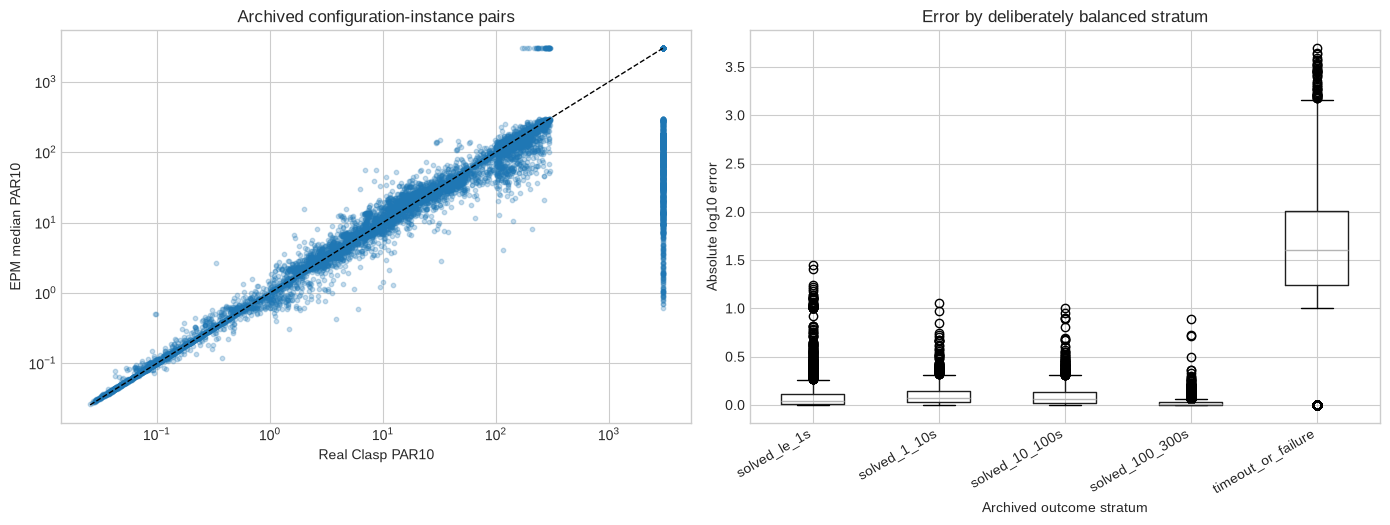

In [4]:
display(pd.Series(summary['point_level'], name='value').to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].scatter(
    points['actual_par10'], points['predicted_median_par10'],
    s=10, alpha=0.25,
)
limits = [
    min(points['actual_par10'].min(), points['predicted_median_par10'].min()),
    max(points['actual_par10'].max(), points['predicted_median_par10'].max()),
]
axes[0].plot(limits, limits, '--', color='black', linewidth=1)
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('Real Clasp PAR10')
axes[0].set_ylabel('EPM median PAR10')
axes[0].set_title('Archived configuration-instance pairs')

stratum_order = [
    'solved_le_1s', 'solved_1_10s', 'solved_10_100s',
    'solved_100_300s', 'timeout_or_failure',
]
points.boxplot(
    column='absolute_log10_error', by='stratum', ax=axes[1],
    positions=np.arange(len(stratum_order)),
)
axes[1].set_xticks(np.arange(len(stratum_order)), stratum_order, rotation=30, ha='right')
axes[1].set_xlabel('Archived outcome stratum')
axes[1].set_ylabel('Absolute log10 error')
axes[1].set_title('Error by deliberately balanced stratum')
fig.suptitle('')
fig.tight_layout()
plt.show()

,predicted_median,actual_median,actual_mean,records
0,0.07741,0.07377,0.07554,1000
1,0.2983,0.2871,15.39,1000
2,2.18,2.162,185.1,1000
3,5.783,5.648,209.8,1000
4,13.4,14.44,766.3,1000
5,26.27,27.48,696.4,1000
6,45.93,102.3,"1,118",1000
7,101.8,125.4,964.4,1000
8,148.4,171.5,"1,051",1000
9,252.1,276.3,"1,399",1000


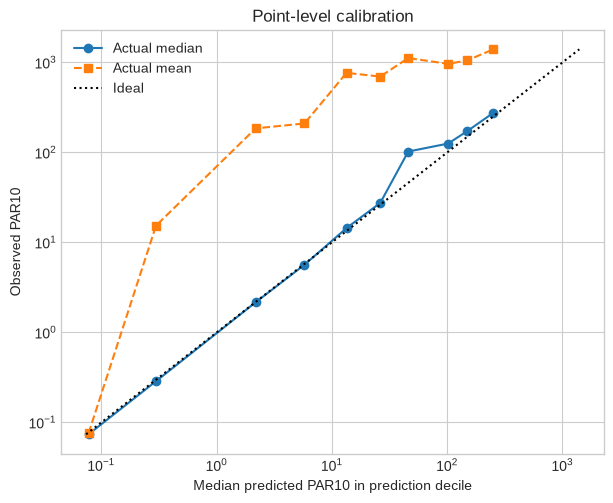

In [5]:
calibration = points.copy()
calibration['predicted_decile'] = pd.qcut(
    calibration['predicted_median_par10'], 10, duplicates='drop'
)
calibration = calibration.groupby('predicted_decile', observed=True).agg(
    predicted_median=('predicted_median_par10', 'median'),
    actual_median=('actual_par10', 'median'),
    actual_mean=('actual_par10', 'mean'),
    records=('actual_par10', 'size'),
).reset_index(drop=True)
display(calibration)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(calibration['predicted_median'], calibration['actual_median'], 'o-', label='Actual median')
ax.plot(calibration['predicted_median'], calibration['actual_mean'], 's--', label='Actual mean')
low = min(calibration['predicted_median'].min(), calibration['actual_median'].min())
high = max(calibration['predicted_median'].max(), calibration['actual_mean'].max())
ax.plot([low, high], [low, high], ':', color='black', label='Ideal')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Median predicted PAR10 in prediction decile')
ax.set_ylabel('Observed PAR10')
ax.set_title('Point-level calibration')
ax.legend()
plt.show()

## 4. Full-training objective

These are the 57 archived configurations with at least one real measurement on every training instance. Repeated solver seeds are averaged within each configuration-instance pair first; the resulting 484 instance means then receive equal weight. This is directly comparable to the full-training incumbent value used in our analytics.

,value
configurations,57
mean_absolute_error,2.122
median_absolute_error,0.8467
spearman_mean_par10,0.9835


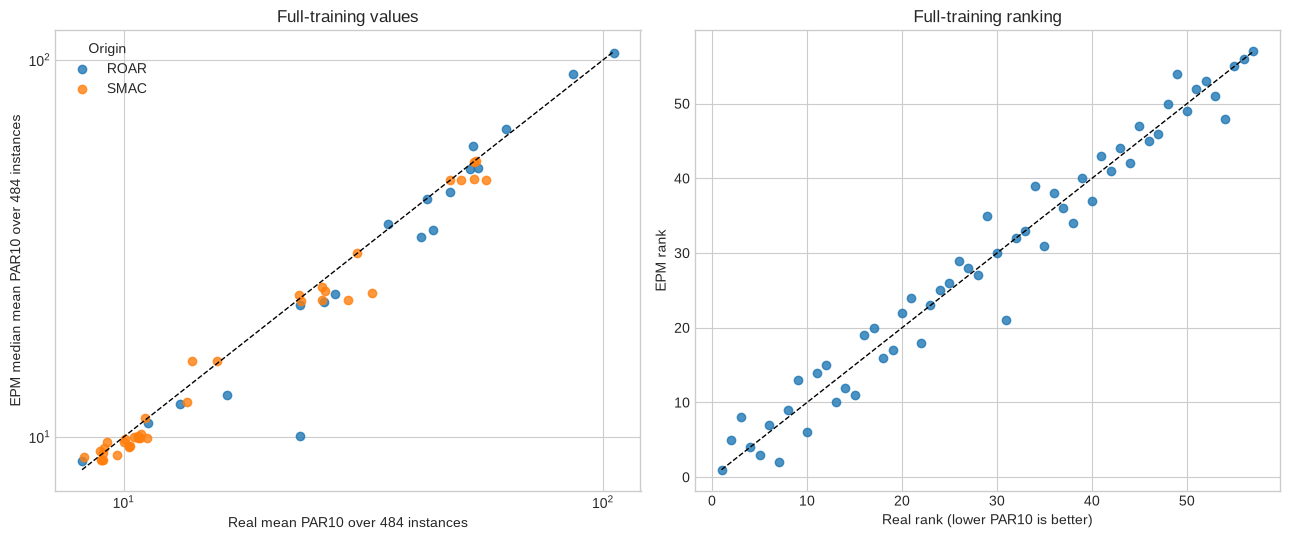

,full_configuration_index,configuration_fingerprint,source_family,source_files,archived_run_records,training_instances,actual_mean_par10,predicted_median_mean_par10,absolute_error,actual_instance_mean_timeout_fraction,predicted_timeout_fraction,real_rank,predicted_rank
31,31,63642b88afa52aa7262a922ded635b36f2fa2c8e6dcbd6...,ROAR,ROAR10,2000,484,8.187,8.625,0.4375,0,0,1,1
47,47,bea3a9d639a6a3777baf7a4daa4b49d28cf1061e2c4b10...,SMAC,SMAC3,1501,484,8.264,8.826,0.5619,0,0,2,5
24,24,4b0d34ef2241ffb3d7732033e7e606b962a58fc8bc0ad7...,SMAC,SMAC3,738,484,8.94,9.188,0.2479,0,0,3,8
2,2,01f9c4b8922d0626f332ea168cea08a664ec28666a1852...,SMAC,SMAC2,2000,484,8.97,8.686,0.2842,0,0,4,4
41,41,a0deb4b9b7b9ebf9246606ad019c0ff31e2c5cbb555917...,SMAC,SMAC2,1772,484,9.01,8.664,0.3468,0,0,5,3
32,32,63d5b3122345a456a9b11c79d175762c3a925c8782a476...,SMAC,SMAC3,631,484,9.043,9.091,0.04832,0,0,6,7
49,49,cf667cf1fb31c584f8949ca10f994d7bd9851e3a6fdc10...,SMAC,SMAC2,1227,484,9.059,8.663,0.3958,0,0,7,2
52,52,d44154fb39fffa7d0108e33705b7272f2f8ef044715c72...,SMAC,SMAC4,1146,484,9.114,9.331,0.2172,0,0,8,9
16,16,365f640a9c4d45204f9fc444cd3709d70d82776eac0a24...,SMAC,SMAC5,1489,484,9.217,9.687,0.4702,0,0,9,13
15,15,346043a606246fa654dedeac82c58e612b7a0205498397...,SMAC,SMAC2,850,484,9.706,8.968,0.7386,0,0,10,6


In [6]:
display(pd.Series(summary['full_training'], name='value').to_frame())
ranked = full.copy()
ranked['real_rank'] = ranked['actual_mean_par10'].rank(method='average')
ranked['predicted_rank'] = ranked['predicted_median_mean_par10'].rank(method='average')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for family, group in ranked.groupby('source_family'):
    axes[0].scatter(
        group['actual_mean_par10'], group['predicted_median_mean_par10'],
        label=family, alpha=0.8,
    )
low = min(ranked['actual_mean_par10'].min(), ranked['predicted_median_mean_par10'].min())
high = max(ranked['actual_mean_par10'].max(), ranked['predicted_median_mean_par10'].max())
axes[0].plot([low, high], [low, high], '--', color='black', linewidth=1)
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('Real mean PAR10 over 484 instances')
axes[0].set_ylabel('EPM median mean PAR10 over 484 instances')
axes[0].set_title('Full-training values')
axes[0].legend(title='Origin')

axes[1].scatter(ranked['real_rank'], ranked['predicted_rank'], alpha=0.8)
axes[1].plot([1, len(ranked)], [1, len(ranked)], '--', color='black', linewidth=1)
axes[1].set_xlabel('Real rank (lower PAR10 is better)')
axes[1].set_ylabel('EPM rank')
axes[1].set_title('Full-training ranking')
fig.tight_layout()
plt.show()

display(ranked.sort_values('actual_mean_par10').head(15))

## 5. Uncertainty calibration

Each selected pair has at least two independent archived Clasp runs. The EPM distribution is approximated by reproducible nonzero quantile seeds; seed zero is reserved for the median. Few real repetitions make pairwise empirical variance noisy, so interval coverage is the more stable aggregate diagnostic.

,value
mean_empirical_50_interval_coverage,0.6218
mean_empirical_90_interval_coverage,0.9492
mean_real_repetitions,3.236
repeated_pairs,500
spearman_standard_deviation,0.7394


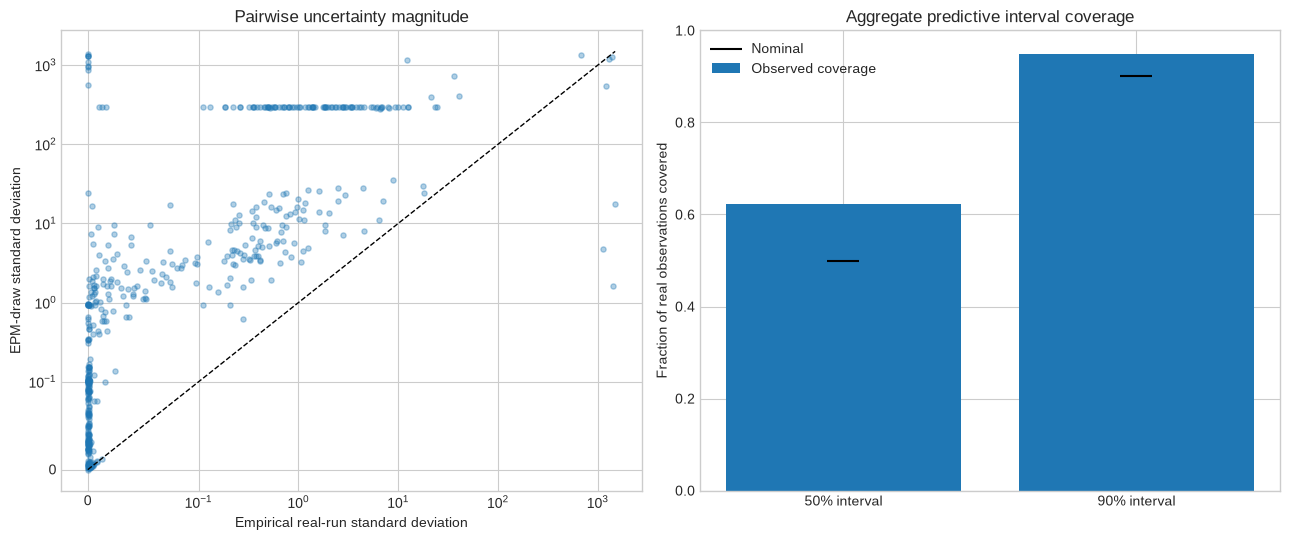

In [7]:
display(pd.Series(summary['uncertainty'], name='value').to_frame())

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].scatter(
    uncertainty['actual_std_par10'], uncertainty['predicted_std_par10'],
    s=14, alpha=0.35,
)
max_std = max(uncertainty['actual_std_par10'].max(), uncertainty['predicted_std_par10'].max())
axes[0].plot([0, max_std], [0, max_std], '--', color='black', linewidth=1)
axes[0].set_xscale('symlog', linthresh=0.1)
axes[0].set_yscale('symlog', linthresh=0.1)
axes[0].set_xlabel('Empirical real-run standard deviation')
axes[0].set_ylabel('EPM-draw standard deviation')
axes[0].set_title('Pairwise uncertainty magnitude')

observed = [
    uncertainty['empirical_50_interval_coverage'].mean(),
    uncertainty['empirical_90_interval_coverage'].mean(),
]
axes[1].bar(['50% interval', '90% interval'], observed, label='Observed coverage')
axes[1].scatter(['50% interval', '90% interval'], [0.5, 0.9], color='black', marker='_', s=500, label='Nominal')
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Fraction of real observations covered')
axes[1].set_title('Aggregate predictive interval coverage')
axes[1].legend()
fig.tight_layout()
plt.show()

## 6. Five-real-seed distribution comparison

This section restricts the analysis to all configuration–instance pairs with exactly five distinct real Clasp seeds. For every identical pair, the five archived PAR10 values are compared with 1,000 draws from the EPM's predictive quantile distribution. These 737 pairs come from 13 configurations and 322 instances. Five observations still provide a coarse empirical distribution, so aggregate patterns across all pairs are more reliable than any single pair's KS p-value.

In [ ]:
display(pd.Series({key: value for key, value in five_seed_summary.items() if key != 'quantile_absolute_errors'}, name='value').to_frame())
quantile_error_table = pd.DataFrame(five_seed_summary['quantile_absolute_errors']).T
quantile_error_table.index.name = 'quantile'
display(quantile_error_table)
print('Real array:', five_seed_actual.shape, 'Surrogate array:', five_seed_predicted.shape)
assert five_seed_actual.shape == (737, 5)
assert five_seed_predicted.shape == (737, 1000)

,value
comparison_version,1
elapsed_seconds,32.78
mean_ks_statistic,0.4438
mean_real_50_interval_coverage,0.6429
mean_real_90_interval_coverage,0.9712
mean_wasserstein_par10,8.681
median_ks_statistic,0.452
median_wasserstein_par10,0.2509
pairs_with_five_distinct_real_seeds,737
random_seed,2.026e+07


,mean_absolute_error,median_absolute_error
quantile,,
q05,3.149,0.04204
q10,3.396,0.03165
q25,1.409,0.005523
q50,1.186,0.01026
q75,6.225,0.1551
q90,9.714,0.2942
q95,17.4,0.4746


Real array: (737, 5) Surrogate array: (737, 1000)


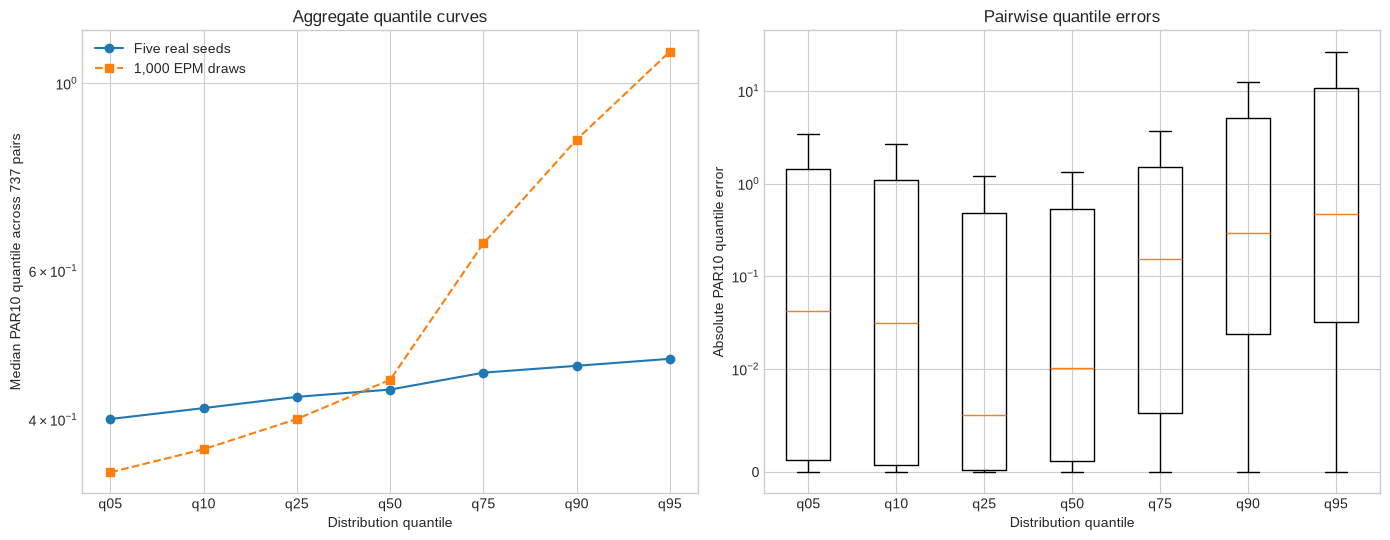

In [ ]:
quantile_labels = ['q05', 'q10', 'q25', 'q50', 'q75', 'q90', 'q95']
quantile_long = pd.concat(
    [
        pd.DataFrame({
            'quantile': label,
            'actual': five_seed_pairs[f'actual_{label}'],
            'predicted': five_seed_pairs[f'predicted_{label}'],
            'absolute_error': five_seed_pairs[f'absolute_{label}_error'],
        })
        for label in quantile_labels
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
aggregate_quantiles = quantile_long.groupby('quantile', sort=False).agg(
    actual_median=('actual', 'median'),
    predicted_median=('predicted', 'median'),
).loc[quantile_labels]
axes[0].plot(quantile_labels, aggregate_quantiles['actual_median'], 'o-', label='Five real seeds')
axes[0].plot(quantile_labels, aggregate_quantiles['predicted_median'], 's--', label='1,000 EPM draws')
axes[0].set_yscale('log')
axes[0].set_xlabel('Distribution quantile')
axes[0].set_ylabel('Median PAR10 quantile across 737 pairs')
axes[0].set_title('Aggregate quantile curves')
axes[0].legend()

error_data = [
    quantile_long.loc[quantile_long['quantile'] == label, 'absolute_error'].to_numpy()
    for label in quantile_labels
]
axes[1].boxplot(error_data, tick_labels=quantile_labels, showfliers=False)
axes[1].set_yscale('symlog', linthresh=0.01)
axes[1].set_xlabel('Distribution quantile')
axes[1].set_ylabel('Absolute PAR10 quantile error')
axes[1].set_title('Pairwise quantile errors')
fig.tight_layout()
plt.show()

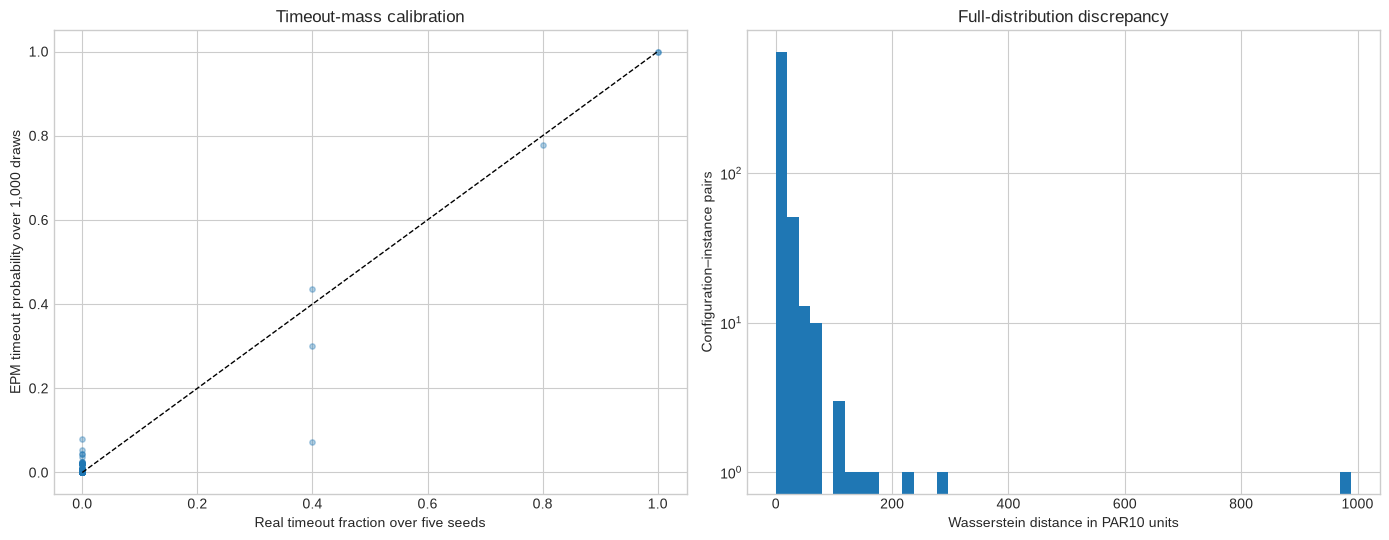

,observed real-value coverage
Predicted 50% interval,0.6429
Predicted 90% interval,0.9712


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].scatter(
    five_seed_pairs['actual_timeout_fraction'],
    five_seed_pairs['predicted_timeout_fraction'],
    s=15, alpha=0.35,
)
axes[0].plot([0, 1], [0, 1], '--', color='black', linewidth=1)
axes[0].set_xlabel('Real timeout fraction over five seeds')
axes[0].set_ylabel('EPM timeout probability over 1,000 draws')
axes[0].set_title('Timeout-mass calibration')

axes[1].hist(five_seed_pairs['wasserstein_par10'], bins=50)
axes[1].set_yscale('log')
axes[1].set_xlabel('Wasserstein distance in PAR10 units')
axes[1].set_ylabel('Configuration–instance pairs')
axes[1].set_title('Full-distribution discrepancy')
fig.tight_layout()
plt.show()

coverage = pd.Series({
    'Predicted 50% interval': five_seed_pairs['real_values_inside_predicted_50_interval'].mean(),
    'Predicted 90% interval': five_seed_pairs['real_values_inside_predicted_90_interval'].mean(),
})
display(coverage.to_frame('observed real-value coverage'))

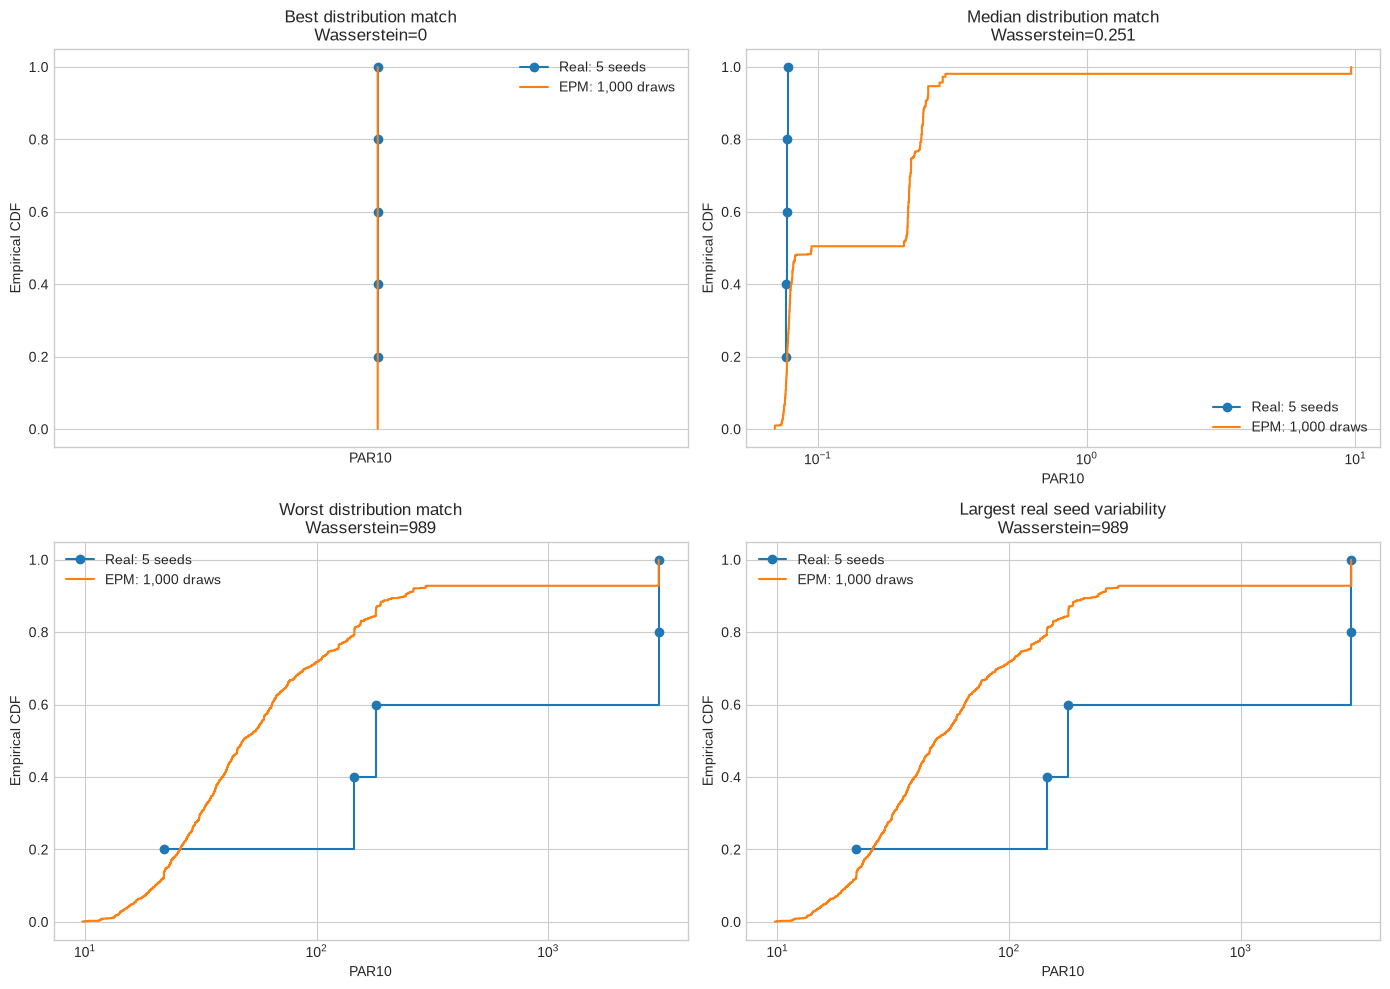

,pair_index,configuration_fingerprint,instance,actual_mean_par10,predicted_mean_par10,actual_std_par10,predicted_std_par10,actual_timeout_fraction,predicted_timeout_fraction,wasserstein_par10,ks_statistic
402,402,44537d2d77d0afe774fda89890a38256476d42ab3214f4...,instances/sat/data/QUEENS-CSSC14/instances/Sat...,"3,000","3,000",0,0,1,1,0,0
658,658,b944a2048a0ce1d881369a1ab148e4d58d8678b76a0160...,instances/sat/data/QUEENS-CSSC14/instances/Sat...,0.08952,0.3403,0.0003219,1.296,0,0,0.2509,0.747
247,247,19c522c8d9a5705d12662b1ceba5c1aeb59a5f576ef005...,instances/sat/data/QUEENS-CSSC14/instances/Sat...,"1,270",280.6,"1,414",759.7,0.4,0.072,989.2,0.593
247,247,19c522c8d9a5705d12662b1ceba5c1aeb59a5f576ef005...,instances/sat/data/QUEENS-CSSC14/instances/Sat...,"1,270",280.6,"1,414",759.7,0.4,0.072,989.2,0.593


In [ ]:
distances = five_seed_pairs['wasserstein_par10']
example_indices = {
    'Best distribution match': int(distances.idxmin()),
    'Median distribution match': int((distances - distances.median()).abs().idxmin()),
    'Worst distribution match': int(distances.idxmax()),
    'Largest real seed variability': int(five_seed_pairs['actual_std_par10'].idxmax()),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (label, pair_index) in zip(axes.flat, example_indices.items()):
    real = np.sort(five_seed_actual[pair_index])
    predicted = np.sort(five_seed_predicted[pair_index])
    ax.step(real, np.arange(1, len(real) + 1) / len(real), where='post', marker='o', label='Real: 5 seeds')
    ax.step(predicted, np.arange(1, len(predicted) + 1) / len(predicted), where='post', label='EPM: 1,000 draws')
    ax.set_xscale('symlog', linthresh=0.1)
    ax.set_xlabel('PAR10')
    ax.set_ylabel('Empirical CDF')
    ax.set_title(f"{label}\nWasserstein={distances.iloc[pair_index]:.3g}")
    ax.legend()
fig.tight_layout()
plt.show()

display(five_seed_pairs.iloc[list(example_indices.values())][[
    'pair_index', 'configuration_fingerprint', 'instance',
    'actual_mean_par10', 'predicted_mean_par10',
    'actual_std_par10', 'predicted_std_par10',
    'actual_timeout_fraction', 'predicted_timeout_fraction',
    'wasserstein_par10', 'ks_statistic',
]])

## 7. Decision summary

In [12]:
messages = []
if summary['wrapper_parity']['all_passed'] and summary['command_line_wrapper']['all_passed']:
    messages.append('PASS: the in-process adapter exactly reproduces the official ACLib numerical request path, and the end-to-end CLI/server transport also agrees.')
else:
    messages.append('FAIL: investigate parameter encoding, feature lookup, cutoff handling, or status conversion before trusting experiments.')
messages.append(
    f"Full-training rank correlation: {summary['full_training']['spearman_mean_par10']:.3f}; "
    f"median absolute mean-PAR10 error: {summary['full_training']['median_absolute_error']:.3f}."
)
messages.append(
    f"Point-level Spearman correlation in the balanced diagnostic sample: "
    f"{summary['point_level']['spearman_par10']:.3f}."
)
messages.append(
    f"For the 737 five-real-seed pairs, real-versus-EPM mean and standard-deviation rank correlations are "
    f"{five_seed_summary['spearman_mean_par10']:.3f} and {five_seed_summary['spearman_std_par10']:.3f}."
)
messages.append(
    'This experiment does not establish accuracy for the 1,000 newly sampled configurations because none occurs in the archive.'
)
print('\n'.join(f'- {message}' for message in messages))

- PASS: the in-process adapter exactly reproduces the official ACLib numerical request path, and the end-to-end CLI/server transport also agrees.
- Full-training rank correlation: 0.984; median absolute mean-PAR10 error: 0.847.
- Point-level Spearman correlation in the balanced diagnostic sample: 0.869.
- For the 737 five-real-seed pairs, real-versus-EPM mean and standard-deviation rank correlations are 0.969 and 0.809.
- This experiment does not establish accuracy for the 1,000 newly sampled configurations because none occurs in the archive.
